# Day 5 — Deep Learning Fundamentals

Colab practice for neuron, perceptron, MLP, forward propagation, activations, losses, backpropagation, gradient descent, epochs/batches, and optimizers.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Artificial Neuron

In [2]:
x = np.array([2.0, 3.0, 1.0])
w = np.array([0.5, -0.2, 0.8])
b = 0.1

z = np.dot(x, w) + b
print("Weighted sum + bias:", z)

Weighted sum + bias: 1.3


## ReLU

In [3]:
values = np.array([-3, -1, 0, 1, 3])
relu = np.maximum(0, values)
print(relu)

[0 0 0 1 3]


## Sigmoid

In [4]:
values = np.array([-4, -2, 0, 2, 4])
sigmoid = 1 / (1 + np.exp(-values))
print(sigmoid)

[0.01798621 0.11920292 0.5        0.88079708 0.98201379]


## Tanh

In [5]:
values = np.array([-3, -1, 0, 1, 3])
print(np.tanh(values))

[-0.99505475 -0.76159416  0.          0.76159416  0.99505475]


## Softmax

In [6]:
scores = np.array([2.0, 1.0, 0.1])
exp_scores = np.exp(scores - np.max(scores))
softmax = exp_scores / exp_scores.sum()
print(softmax)
print("Sum:", softmax.sum())

[0.65900114 0.24243297 0.09856589]
Sum: 1.0


## Activation Functions Plot

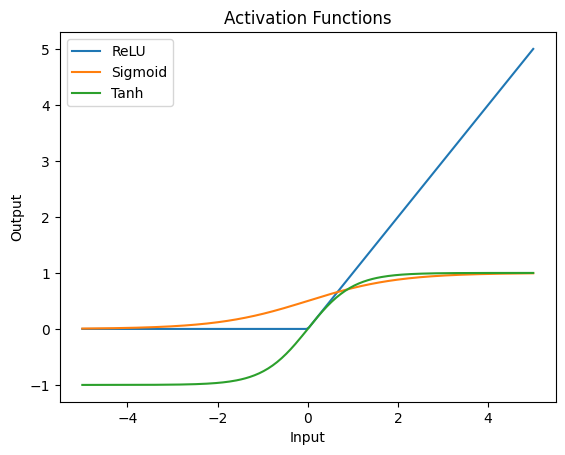

In [7]:
x = np.linspace(-5, 5, 200)

plt.plot(x, np.maximum(0, x), label="ReLU")
plt.plot(x, 1/(1+np.exp(-x)), label="Sigmoid")
plt.plot(x, np.tanh(x), label="Tanh")
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Activation Functions")
plt.legend()
plt.show()

## Perceptron Example

In [8]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
weights = np.array([1.0, 1.0])
bias = -1.5

for sample in X:
    z = np.dot(sample, weights) + bias
    out = 1 if z > 0 else 0
    print(sample, "->", out)

[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


## Build a Small MLP

In [9]:
model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37 (148.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

## Forward Propagation

In [10]:
sample = np.array([[0.6, 0.2]], dtype=np.float32)
prediction = model(sample)
print(prediction.numpy())

[[0.48719484]]


## Mean Squared Error

In [11]:
y_true = np.array([3.0, 5.0, 2.0])
y_pred = np.array([2.5, 5.5, 2.2])

mse = np.mean((y_true - y_pred)**2)
print("MSE:", mse)

MSE: 0.18000000000000002


## Binary Cross-Entropy

In [12]:
y_true = tf.constant([1.0, 0.0, 1.0])
y_pred = tf.constant([0.9, 0.2, 0.7])

loss = keras.losses.BinaryCrossentropy()(y_true, y_pred)
print("Binary Cross-Entropy:", float(loss))

Binary Cross-Entropy: 0.22839301824569702


## Categorical Cross-Entropy

In [13]:
y_true = tf.constant([[0,1,0]], dtype=tf.float32)
y_pred = tf.constant([[0.1,0.8,0.1]], dtype=tf.float32)

loss = keras.losses.CategoricalCrossentropy()(y_true, y_pred)
print("Categorical Cross-Entropy:", float(loss))

Categorical Cross-Entropy: 0.2231435328722


## Simple Gradient Descent

In [14]:
w = 5.0
learning_rate = 0.1

for step in range(10):
    gradient = 2 * w
    w = w - learning_rate * gradient
    print(step + 1, w)

1 4.0
2 3.2
3 2.56
4 2.048
5 1.6384
6 1.31072
7 1.0485760000000002
8 0.8388608000000002
9 0.6710886400000001
10 0.5368709120000001


## Backpropagation with GradientTape

In [15]:
w = tf.Variable(3.0)

with tf.GradientTape() as tape:
    loss = w**2

gradient = tape.gradient(loss, w)

print("Loss:", float(loss))
print("Gradient:", float(gradient))

Loss: 9.0
Gradient: 6.0


## One Weight Update

In [16]:
w = tf.Variable(3.0)
learning_rate = 0.1

with tf.GradientTape() as tape:
    loss = w**2

gradient = tape.gradient(loss, w)
w.assign_sub(learning_rate * gradient)

print("Updated weight:", float(w))

Updated weight: 2.4000000953674316


## Prepare Tiny Classification Data

In [17]:
X = np.array([
    [0.0,0.0],
    [0.0,1.0],
    [1.0,0.0],
    [1.0,1.0]
], dtype=np.float32)

y = np.array([0,1,1,1], dtype=np.float32)

print(X)
print(y)

[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
[0. 1. 1. 1.]


## Model Builder

In [18]:
def build_model():
    return keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

## Train with SGD

In [19]:
model_sgd = build_model()
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history_sgd = model_sgd.fit(X, y, epochs=100, verbose=0)
print("Final SGD accuracy:", history_sgd.history["accuracy"][-1])

Final SGD accuracy: 1.0


## Train with Momentum

In [20]:
model_momentum = build_model()
model_momentum.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history_momentum = model_momentum.fit(X, y, epochs=100, verbose=0)
print("Final Momentum accuracy:", history_momentum.history["accuracy"][-1])

Final Momentum accuracy: 1.0


## Train with RMSProp

In [21]:
model_rms = build_model()
model_rms.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history_rms = model_rms.fit(X, y, epochs=100, verbose=0)
print("Final RMSProp accuracy:", history_rms.history["accuracy"][-1])

Final RMSProp accuracy: 1.0


## Train with Adam

In [22]:
model_adam = build_model()
model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history_adam = model_adam.fit(X, y, epochs=100, verbose=0)
print("Final Adam accuracy:", history_adam.history["accuracy"][-1])

Final Adam accuracy: 0.75


## Compare Optimizer Loss

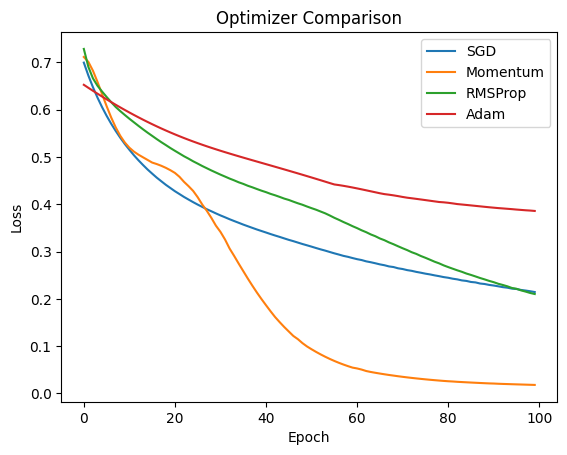

In [23]:
plt.plot(history_sgd.history["loss"], label="SGD")
plt.plot(history_momentum.history["loss"], label="Momentum")
plt.plot(history_rms.history["loss"], label="RMSProp")
plt.plot(history_adam.history["loss"], label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()

## Epoch, Batch Size, Iteration

In [24]:
dataset_size = 1000
batch_size = 100

iterations_per_epoch = dataset_size // batch_size

print("Dataset size:", dataset_size)
print("Batch size:", batch_size)
print("Iterations per epoch:", iterations_per_epoch)

Dataset size: 1000
Batch size: 100
Iterations per epoch: 10


## Mini-Batch Training

In [25]:
mini_batch_model = build_model()
mini_batch_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
mini_batch_model.fit(X, y, epochs=20, batch_size=2, verbose=0)
print("Mini-batch training complete.")

Mini-batch training complete.


## Final Predictions

In [26]:
predictions = model_adam.predict(X, verbose=0)

for sample, prob in zip(X, predictions):
    print(sample, "->", float(prob[0]))

[0. 0.] -> 0.6051678657531738
[0. 1.] -> 0.6051678657531738
[1. 0.] -> 0.9511410593986511
[1. 1.] -> 0.9426681995391846


## Quick Summary Table

In [27]:
pd.DataFrame({
    "Concept": [
        "Neuron","Perceptron","MLP","Forward Propagation",
        "ReLU","Sigmoid","Softmax","Loss",
        "Backpropagation","Gradient Descent",
        "SGD","Momentum","RMSProp","Adam"
    ],
    "Memory Point": [
        "Inputs + weights + bias + activation",
        "Simple linear classifier",
        "Multi-layer fully connected network",
        "Input to prediction",
        "Hidden layer activation",
        "Binary output",
        "Multiclass output",
        "Prediction error",
        "Calculates gradients",
        "Updates weights",
        "Basic optimizer",
        "Uses previous direction",
        "Adaptive learning rate",
        "Momentum + adaptive learning rate"
    ]
})

,Concept,Memory Point
0,Neuron,Inputs + weights + bias + activation
1,Perceptron,Simple linear classifier
2,MLP,Multi-layer fully connected network
3,Forward Propagation,Input to prediction
4,ReLU,Hidden layer activation
5,Sigmoid,Binary output
6,Softmax,Multiclass output
7,Loss,Prediction error
8,Backpropagation,Calculates gradients
9,Gradient Descent,Updates weights
